# Análise e Teste de LSTM - Treinamento Local

Este notebook implementa localmente todo o workflow de treinamento de uma LSTM para predição de movimentos de mercado, seguindo a mesma arquitetura e parâmetros utilizados no projeto WTNPS Trade.

**Objetivo:** Treinar uma LSTM do zero e analisar sua performance através de métricas de classificação.

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import MetaTrader5 as mt5
from datetime import datetime, timedelta
import pytz

from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
# from sklearn.model_selection import train_test_split

# Métricas para regressão e classificação
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error

# Correlações (relevantes para regressão, como no notebook de referência)
# from scipy.stats import pearsonr, spearmanr

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotecas importadas com sucesso!")

# Inicializar MT5
if not mt5.initialize():
    print(f"Erro ao inicializar MT5: {mt5.last_error()}")
    raise Exception("Falha na inicialização do MetaTrader 5")

print(f"MT5 inicializado com sucesso!")
print(f"Versão: {mt5.version()}")

Bibliotecas importadas com sucesso!
MT5 inicializado com sucesso!
Versão: (500, 5370, '17 Oct 2025')


## 2. Parâmetros de Configuração

Definição local de todos os parâmetros utilizados no treinamento.

In [2]:
# Parâmetros do ativo e dados
TICKER = "WDO$"  # Ou "WDO$" conforme preferência
timeframe_str = "H1"  # Timeframe
START_DATE = datetime(2020, 1, 1)  # Data de início
END_DATE = datetime(2024, 12, 31)  # Data de fim

# Parâmetros da LSTM
LOOKBACK = 30  # Janela de lookback (N candles anteriores)
LSTM_UNITS = 100  # Unidades LSTM
EPOCHS = 100         # Número de épocas
BATCH_SIZE = 128  # Tamanho do batch
TARGET_PERIOD = 5  # Período de previsão (N candles)

# Parâmetros de divisão de dados
TEST_SIZE = 0.3  # 30% para teste
VALIDATION_SPLIT = 0.1  # 10% do treino para validação

# Timezone
TIMEZONE_SP = pytz.timezone('Etc/UTC')

tp_map = { "M1": mt5.TIMEFRAME_M1, "M5": mt5.TIMEFRAME_M5, "M15": mt5.TIMEFRAME_M15,
                 "M30": mt5.TIMEFRAME_M30, "H1": mt5.TIMEFRAME_H1, "H4": mt5.TIMEFRAME_H4,
                 "D1": mt5.TIMEFRAME_D1, "W1": mt5.TIMEFRAME_W1, "MN1": mt5.TIMEFRAME_MN1 }

TIMEFRAME = tp_map.get(timeframe_str.upper(), mt5.TIMEFRAME_D1)

print(f"Configuração:")
print(f"  Ticker: {TICKER}")
print(f"  Período: {START_DATE.date()} a {END_DATE.date()}")
print(f"  Timeframe: {timeframe_str}")
print(f"  Lookback: {LOOKBACK}")
print(f"  LSTM Units: {LSTM_UNITS}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Target Period: {TARGET_PERIOD}")
print(f"  Test Size: {TEST_SIZE}")
print(f"  Validation Split: {VALIDATION_SPLIT}")

Configuração:
  Ticker: WDO$
  Período: 2020-01-01 a 2024-12-31
  Timeframe: H1
  Lookback: 30
  LSTM Units: 100
  Epochs: 100
  Batch Size: 128
  Target Period: 5
  Test Size: 0.3
  Validation Split: 0.1


## 3. Coleta de Dados

In [3]:
# Converter datas para UTC (MT5 trabalha em UTC)
start_date_utc = TIMEZONE_SP.localize(START_DATE).astimezone(pytz.UTC)
end_date_utc = TIMEZONE_SP.localize(END_DATE).astimezone(pytz.UTC)

print(f"\nBuscando dados de {TICKER}...")
print(f"  Período UTC: {start_date_utc} a {end_date_utc}")

# Buscar dados históricos
rates = mt5.copy_rates_range(TICKER, TIMEFRAME, start_date_utc, end_date_utc)

if rates is None or len(rates) == 0:
    print(f"Erro ao buscar dados: {mt5.last_error()}")
    mt5.shutdown()
    raise Exception("Nenhum dado retornado do MT5")

print(f"\n✓ {len(rates)} candles coletados com sucesso!")


# Converter para DataFrame
df_raw = pd.DataFrame(rates)

df_raw['time'] = pd.to_datetime(df_raw['time'], unit='s', utc=True)
df_raw['time'] = df_raw['time'].dt.tz_convert(TIMEZONE_SP)
df_raw.set_index('time', inplace=True)

# Renomear colunas para padrão do projeto
df_raw.columns = ['open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
df_raw.rename(columns={'tick_volume': 'volume'}, inplace=True)

print(f"\nPrimeiros registros:")
print(df_raw.head())
print(f"\nÚltimos registros:")
print(df_raw.tail())

# salva drf em csv
df_raw.to_csv("c:\\projects\\wtnps-trade\\archive\\data\\wdo$_mt5_rates_H1_20220101_20241231_raw.csv", index=False)

# Desligar MT5
mt5.shutdown()
print("\nMT5 desconectado.")


Buscando dados de WDO$...
  Período UTC: 2020-01-01 00:00:00+00:00 a 2024-12-31 00:00:00+00:00

✓ 9766 candles coletados com sucesso!

Primeiros registros:
                               open      high       low     close  volume  \
time                                                                        
2020-11-16 09:00:00+00:00  7290.539  7293.224  7204.626  7235.501  247465   
2020-11-16 10:00:00+00:00  7236.172  7284.499  7235.501  7260.336  196933   
2020-11-16 11:00:00+00:00  7260.336  7316.045  7257.651  7305.306  154054   
2020-11-16 12:00:00+00:00  7304.635  7329.469  7285.841  7290.539  121478   
2020-11-16 13:00:00+00:00  7291.211  7293.224  7249.596  7252.281  110821   

                           spread  real_volume  
time                                            
2020-11-16 09:00:00+00:00       1       711623  
2020-11-16 10:00:00+00:00       1       578437  
2020-11-16 11:00:00+00:00       1       487813  
2020-11-16 12:00:00+00:00       1       391042  
2020-11-1

## 4. Criação de Features (Indicadores Técnicos)

Implementação local das mesmas features utilizadas na estratégia LSTM do projeto.

In [4]:
from IPython.display import display, HTML

# --- Funções Auxiliares ---

def calculate_true_range(df):
    """Calcula o True Range (TR) para o DataFrame."""
    df_temp = df.copy()
    df_temp['high-low'] = df_temp['high'] - df_temp['low']
    df_temp['high-prev_close'] = np.abs(df_temp['high'] - df_temp['close'].shift(1))
    df_temp['low-prev_close'] = np.abs(df_temp['low'] - df_temp['close'].shift(1))
    df_temp['true_range'] = df_temp[['high-low', 'high-prev_close', 'low-prev_close']].max(axis=1)
    df.drop(columns=['high-low', 'high-prev_close', 'low-prev_close'], inplace=True, errors='ignore')
    return df_temp['true_range']

def print_analysis_summary(df_vol, df_retornos, df_alvos):
    """Imprime um resumo interpretativo da análise de target."""
    
    try:
        # --- CORREÇÃO APLICADA AQUI ---
        # O nome da coluna de volatilidade percentual é 'atr_norm'
        atr_pct_mediana = df_vol['atr_norm'].median()
        atr_pct_q75 = df_vol['atr_norm'].quantile(0.75)
        # --- FIM DA CORREÇÃO ---
        
        # 2. Retorno (A Oportunidade) - Usando 5H como exemplo
        retorno_mediano_5h = df_retornos.loc['5H']['Mediana (50%) (%)']
        retorno_q75_5h = df_retornos.loc['5H']['Quartil Sup. (75%) (%)']
        
        # 3. Acessibilidade (O Balanceamento)
        # Tenta encontrar um alvo balanceado (ex: 5H, 1.0x ATR)
        alvo_exemplo = df_alvos[
            (df_alvos['Horizonte'] == '5H') & 
            (df_alvos['Limiar (ATR)'] == '1.0x ATR')
        ]
        if not alvo_exemplo.empty:
            pct_up = alvo_exemplo['% Alvos UP'].values[0]
            pct_down = alvo_exemplo['% Alvos DOWN'].values[0]
            pct_neutro = alvo_exemplo['% Neutro'].values[0] # <-- NOVO
            balanceamento = f"{pct_up:.1f}% (UP) / {pct_neutro:.1f}% (NEUTRO) / {pct_down:.1f}% (DOWN)"
        else:
            balanceamento = "N/A (Verificar tabela)"

        summary_html = f"""
        <div style="border: 2px solid #007BFF; padding: 15px; border-radius: 8px; background-color: #f4f8ff; font-family: Arial, sans-serif; line-height: 1.6;">
        <h3 style="color: #004085; border-bottom: 2px solid #b8cffc; padding-bottom: 5px;">📜 Resumo da Análise de Dados (WDO$ - H1)</h3>
        
        <p>Esta análise nos ajuda a definir uma "pergunta" (target) que seja justa e acessível para o assistente.</p>
        
        <h4>1. Qual é o "Ruído" Normal do Mercado? (Volatilidade)</h4>
        <ul>
            <li><strong>ATR Mediano (<code>atr_norm</code> 50%):</strong> {atr_pct_mediana:,.4f}%</li>
            <li><strong>ATR Quartil 75% (<code>atr_norm</code> 75%):</strong> {atr_pct_q75:,.4f}%</li>
        </ul>
        <p><strong>Interpretação:</strong> Metade dos candles (horas) se move <em>menos</em> que {atr_pct_mediana:,.4f}%. Um alvo de <strong>0.5%</strong> (usado anteriormente) era {0.5/atr_pct_mediana:.1f}x maior que o "ruído" mediano, por isso era tão raro.</p>

        <h4>2. Qual é a "Oportunidade" Real? (Retornos Futuros)</h4>
        <ul>
            <li><strong>Retorno Mediano em 5 Horas:</strong> {retorno_mediano_5h:,.4f}%</li>
            <li><strong>Retorno Quartil 75% em 5 Horas:</strong> {retorno_q75_5h:,.4f}%</li>
        </ul>
        <p><strong>Interpretação:</strong> Em 5 horas, 75% dos movimentos de alta foram <em>menores</em> que {retorno_q75_5h:,.4f}%. Isso ajuda a calibrar nossa expectativa de limiar (threshold).</p>
        
        <h4>3. Qual "Pergunta" (Target) Devemos Fazer?</h4>
        <ul>
            <li><strong>Análise de Acessibilidade (Exemplo: 5H, 1.0x ATR):</strong> {balanceamento}</li>
        </ul>
        <p><strong>Interpretação:</strong> A tabela "Acessibilidade de Alvos" é a mais importante. Veja como o alvo 'Neutro' (ex: 53%) é a classe dominante. Nosso modelo binário antigo estava misturando 'Neutro' e 'DOWN', o que o confundia.</p>
        
        <hr style="border: 0; border-top: 1px solid #b8cffc;">
        
        <h4>⭐ SUGESTÕES PARA PRÓXIMA RODADA:</h4>
        <ol>
            <li>
                <strong>Target Sugerido (Multiclasse):</strong><br>
                Mudar o modelo para prever 3 classes (ALTA, NEUTRO, BAIXA).
                O alvo <strong>Horizonte=5H</strong> e <strong>Limiar=1.0x ATR</strong> parece um bom começo, dando um balanceamento de aprox. 24% UP / 53% NEUTRO / 23% DOWN.
            </li>
            <li>
                <strong>Features Mais Relevantes (Pistas):</strong><br>
                Para prever "explosões" (UP/DOWN) vs "calmaria" (NEUTRO), as pistas mais importantes serão:<br>
                <code>'rsi'</code> (cansaço), <code>'band_width'</code> (largura das bandas) e a própria <code>'atr_norm'</code> (o "ruído" atual).<br>
                <em>(Você já as adicionou na Célula 5. Perfeito!)</em>
            </li>
        </ol>
        </div>
        """
        display(HTML(summary_html))
        
    except Exception as e:
        print(f"Erro ao gerar resumo: {e}. Verifique as colunas das tabelas de análise.")

# --- Função Principal de Análise ---

def analisar_potencial_target(df_raw, atr_period=14, max_horizon=10):
    """
    Executa a análise completa de volatilidade, retornos e acessibilidade de alvos.
    """
    print("--- Analisando Volatilidade e Potencial de Target ---")
    df = df_raw.copy()
    
    # --- 1. Análise de Volatilidade (ATR) ---
    df['pct_return'] = df['close'].pct_change() * 100 # Em percentual
    df['true_range'] = calculate_true_range(df)
    df['atr'] = df['true_range'].rolling(window=atr_period).mean()
    df['atr_norm'] = (df['atr'] / df['close']) * 100 # ATR em Percentual
    df.dropna(inplace=True)
    
    print("\n📊 ESTATÍSTICAS DE VOLATILIDADE (H1 - 1 Candle):")
    print("   Isso mostra o movimento 'normal' por hora (em %).")
    stats_df_vol = df[['pct_return', 'atr_norm']].describe(percentiles=[.25, .5, .75, .95, .99])
    display(stats_df_vol.style.format("{:,.4f}%"))

    # --- 2. Análise de Retornos Futuros ---
    print(f"\n📈 ANÁLISE DE RETORNOS FUTUROS (Até {max_horizon} horas):")
    print("   Isso mostra o quanto o preço 'anda' (em %) em diferentes horizontes.")
    results_retornos = []
    df_analysis = df.iloc[:-max_horizon] 
    
    for period in range(1, max_horizon + 1):
        future_return_pct = (df['close'].shift(-period).loc[df_analysis.index] / df_analysis['close'] - 1) * 100
        desc = future_return_pct.describe(percentiles=[.25, .5, .75, .95, .99])
        results_retornos.append({
            'Horizonte (Horas)': f"{period}H",
            'Média (%)': desc['mean'],
            'Mediana (50%) (%)': desc['50%'],
            'Quartil Sup. (75%) (%)': desc['75%'],
            'Top 5% (95%) (%)': desc['95%'],
            'Top 1% (99%) (%)': desc['99%']
        })
    df_retornos = pd.DataFrame(results_retornos).set_index('Horizonte (Horas)')
    print(df_retornos.to_string(float_format='{:,.4f}'.format))

    # --- 3. (ATUALIZADO) Análise de Acessibilidade de Alvos ---
    print(f"\n🔬 ANÁLISE DE ACESSIBILIDADE DE ALVOS (Target Balance):")
    print("   Isso mostra o % de vezes que um alvo (baseado no ATR) seria atingido.")
    
    horizons_to_test = [1, 2, 3, 5, 8] # Horizontes (TARGET_PERIOD)
    atr_multipliers = [0.5, 1.0, 1.5, 2.0] # Limiares (Thresholds)
    
    target_results = []
    
    for period in horizons_to_test:
        future_close = df['close'].shift(-period)
        future_return = (future_close - df['close']) # Retorno absoluto
        
        for m in atr_multipliers:
            threshold_abs = df['atr'] * m
            
            # Calcula % de alvos de ALTA (UP) e BAIXA (DOWN)
            target_up = (future_return > threshold_abs).mean() * 100
            target_down = (future_return < -threshold_abs).mean() * 100
            target_neutro = 100 - (target_up + target_down) # <-- NOVO
            
            target_results.append({
                'Horizonte': f"{period}H",
                'Limiar (ATR)': f"{m:.1f}x ATR",
                '% Alvos UP': target_up,
                '% Alvos DOWN': target_down,
                '% Neutro': target_neutro, # <-- NOVO
                '% Total (UP+DOWN)': target_up + target_down
            })
            
    df_alvos = pd.DataFrame(target_results)
    # Reordenar colunas para melhor leitura
    df_alvos = df_alvos[['Horizonte', 'Limiar (ATR)', '% Alvos UP', '% Neutro', '% Alvos DOWN', '% Total (UP+DOWN)']]
    print(df_alvos.to_string(float_format='{:,.2f}%'.format))
    print("\n" + "="*60)

    # --- 4. (ATUALIZADO) Resumo da Análise ---
    # Passamos o 'df' (que contém 'atr_norm') como df_vol
    print_analysis_summary(df, df_retornos, df_alvos)
    print("\n" + "="*60)
    
    return df, df_retornos, df_alvos

# --- Chame a função aqui ---
# (Assumindo que 'df_raw' foi carregado na Célula 4)
# (O df_volatilidade agora contém as colunas 'atr' e 'atr_norm' que podem ser usadas na Célula 5)
df_volatilidade, df_retornos_futuros, df_alvos = analisar_potencial_target(df_raw, max_horizon=10)

--- Analisando Volatilidade e Potencial de Target ---

📊 ESTATÍSTICAS DE VOLATILIDADE (H1 - 1 Candle):
   Isso mostra o movimento 'normal' por hora (em %).


,pct_return,atr_norm
count,"9,753.0000%","9,753.0000%"
mean,-0.0004%,0.4330%
std,0.3113%,0.1395%
min,-2.7079%,0.1210%
25%,-0.1412%,0.3320%
50%,0.0000%,0.4185%
75%,0.1443%,0.5195%
95%,0.4840%,0.6741%
99%,0.8800%,0.8393%
max,2.3964%,1.2508%



📈 ANÁLISE DE RETORNOS FUTUROS (Até 10 horas):
   Isso mostra o quanto o preço 'anda' (em %) em diferentes horizontes.
                   Média (%)  Mediana (50%) (%)  Quartil Sup. (75%) (%)  Top 5% (95%) (%)  Top 1% (99%) (%)
Horizonte (Horas)                                                                                          
1H                   -0.0003             0.0000                  0.1444            0.4839            0.8801
2H                   -0.0007             0.0000                  0.2208            0.6962            1.2575
3H                   -0.0009             0.0000                  0.2866            0.8787            1.4250
4H                   -0.0012             0.0000                  0.3349            1.0228            1.6520
5H                   -0.0015             0.0000                  0.3859            1.1483            1.7761
6H                   -0.0018            -0.0089                  0.4298            1.2481            1.9137
7H               

In [5]:
def create_features(df):
    """
    Cria indicadores técnicos como features.
    Mesma lógica de LSTMStrategy.define_features()
    """
    df = df.copy()
    
    # Médias Móveis
    df['ema_9'] = df['close'].ewm(span=9, adjust=False).mean()
    df['sma_20'] = df['close'].rolling(window=20).mean()
    # df['sma_50'] = df['close'].rolling(window=50).mean()
    df['sma_200'] = df['close'].rolling(window=200).mean()

    # Na Célula 5, dentro de create_features, após as SMAs:

    # 1. RSI (Índice de Força Relativa) - Mede "cansaço"
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    df['rsi'] = df['rsi'].fillna(50) # Preenche NaNs iniciais com 50 (neutro)

    # 2. Bandas de Bollinger (Largura) - Mede "volatilidade"
    df['sma_20_bb'] = df['close'].rolling(window=20).mean()
    df['std_20_bb'] = df['close'].rolling(window=20).std()
    df['upper_band'] = df['sma_20_bb'] + (df['std_20_bb'] * 2)
    df['lower_band'] = df['sma_20_bb'] - (df['std_20_bb'] * 2)
    df['band_width'] = (df['upper_band'] - df['lower_band']) / df['sma_20_bb'] # Largura normalizada
    df['band_width'] = df['band_width'].fillna(0)

    # Distância do preço à média móvel
    df['dist_sma_20'] = (df['close'] - df['sma_20']) / df['close']
    df['dist_sma_200'] = (df['close'] - df['sma_200']) / df['close']
    
    df['dist_sma_20'] = df['dist_sma_20'].fillna(0)  # Preenche NaNs iniciais
    df['dist_sma_200'] = df['dist_sma_200'].fillna(0)  # Preenche NaNs iniciais

    df['true_range'] = calculate_true_range(df)
    df['atr'] = df['true_range'].rolling(window=14).mean()
    df['atr_norm'] = df['atr'] / df['close']

    price_features = ['ema_9', 'sma_20', 'sma_200']
    for col in price_features:
        df[col] = (df[col] / df['close']) - 1  # Normaliza pelo preço de fechamento
        
    # Remove colunas auxiliares
    df = df.drop(columns=['returns'], errors='ignore')
    
    # Preenche NaNs
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    
    return df

print("Criando features...")
df_features = create_features(df_raw)

# Features que serão usadas no modelo
FEATURE_NAMES = ['ema_9', 'sma_20', 'sma_200', 'dist_sma_20', 'dist_sma_200', 'volume', 'rsi', 'band_width', 'atr_norm'] 

df_features.to_csv("c:\\projects\\wtnps-trade\\archive\\data\\wdo$_20220101_20241231_features.csv", index=False)        

print(f"\n✓ Features criadas: {FEATURE_NAMES}")
print(f"\nEstatísticas das features:")
print(df_features[FEATURE_NAMES].describe())
    

Criando features...

✓ Features criadas: ['ema_9', 'sma_20', 'sma_200', 'dist_sma_20', 'dist_sma_200', 'volume', 'rsi', 'band_width', 'atr_norm']

Estatísticas das features:
             ema_9       sma_20      sma_200  dist_sma_20  dist_sma_200  \
count  9766.000000  9766.000000  9766.000000  9766.000000   9766.000000   
mean      0.000053     0.000144     0.001725    -0.000123     -0.000967   
std       0.004075     0.007538     0.022510     0.007523      0.021922   
min      -0.022453    -0.041277    -0.064078    -0.036348     -0.078384   
25%      -0.002291    -0.004436    -0.012976    -0.004697     -0.015490   
50%       0.000070     0.000101     0.000284    -0.000059      0.000000   
75%       0.002451     0.004745     0.017100     0.004436      0.012976   
max       0.023926     0.036348     0.078384     0.041277      0.064078   

              volume          rsi   band_width     atr_norm  
count    9766.000000  9766.000000  9766.000000  9766.000000  
mean    96816.888388    49

## 5. Criação do Target (Rótulo)

Target Multiclasse: (2=UP, 1=NEUTRO, 0=DOWN)



In [ ]:
def create_target(df):
    """
    Cria a coluna 'target' com base em um movimento futuro (multiclasse).
    Classe 2: ALTA (future_close > close + 1.0 * atr)
    Classe 0: BAIXA (future_close < close - 1.0 * atr)
    Classe 1: NEUTRO (todos os outros)
    """
    print(f"\n--- 3. Criando Target (Gabarito) Multiclasse ---")
    
    # Parâmetro do Limiar (Threshold)
    ATR_MULTIPLIER = 1.0 
    
    # Calcula o 'future_close' e o 'threshold' (limiar)
    df['future_close'] = df['close'].shift(-TARGET_PERIOD)
    df['threshold_atr'] = df['atr'] * ATR_MULTIPLIER
    
    # Limpar NaNs criados pelo shift
    df.dropna(subset=['future_close'], inplace=True)
    
    # --- Lógica Multiclasse com np.select ---
    conditions = [
        df['future_close'] > (df['close'] + df['threshold_atr']), # Condição para ALTA (Classe 2)
        df['future_close'] < (df['close'] - df['threshold_atr'])  # Condição para BAIXA (Classe 0)
    ]
    
    # Lista de escolhas (2 para ALTA, 0 para BAIXA)
    choices = [2, 0]
    
    # 'default=1' significa que se nenhuma condição for atendida, será NEUTRO (Classe 1)
    df['target'] = np.select(conditions, choices, default=1)
    # --- Fim da Lógica ---
    
    # Análise do balanceamento
    print(f"✓ Target multiclasse criado com Horizonte={TARGET_PERIOD} e Limiar={ATR_MULTIPLIER}x ATR.")
    print("Distribuição das classes:")
    print(df['target'].value_counts(normalize=True).sort_index().to_string(float_format='{:.2%}'.format))

    # Selecionar colunas finais
    final_cols = FEATURE_NAMES + ['target']
    df_clean = df[final_cols].copy()
    
    # Remover NaNs das features (gerados por SMAs, RSI, etc.)
    df_clean.bfill(inplace=True) # Preenche NaNs iniciais com valores seguintes
    df_clean.dropna(inplace=True) # Garante que não há mais NaNs
    
    # Salvar
    df_clean.to_csv("c:\\projects\\wtnps-trade\\archive\\data\\wdo$_20220101_20241231_clean.csv", index=False)
    print(f"\n✓ Dados limpos")
    print(f"  Shape final (features + target): {df_clean.shape}")   
    
    return df_clean

# --- Chame a função aqui ---
# (Assumindo que 'df_features' existe da Célula 5)
df_clean = create_target(df_features)

"""
# Target Anterior (Binario)

def create_target(df, target_period=TARGET_PERIOD):
    
    # Cria target contínuo: retorno futuro percentual em relação ao close atual.
    # Vamos perguntar se o preço subirá mais que a volatilidade média de 1 candle.
    # Isso torna a pergunta adaptativa ao mercado
    
    df = df.copy()
    
    df['future_close'] = df['close'].shift(-target_period)
    df['target'] = (df['future_close'] > (df['close'] + (df['atr'] * 1.0))).astype(int)
    
    # Targets anteriores
    # df['target'] = (df['future_close'] > (df['close'] * 1.005)) .astype(int)
    # df['target'] = (df['future_close'] / df['close']) - 1.0
    
    return df['target']

print("Criando target (retorno futuro)...")
df_features['target'] = create_target(df_features, TARGET_PERIOD)

# Remove linhas com NaN (últimas linhas sem target)
df_clean = df_features[FEATURE_NAMES + ['target']].dropna()

df_clean.to_csv("c:\\projects\\wtnps-trade\\archive\\data\\wdo$_20220101_20241231_clean.csv", index=False)

print(f"\n✓ Target criado (regressão: retorno contínuo)")
print(f"\nEstatísticas do target (retorno):")
print(df_clean['target'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
print(f"\nTotal de amostras após limpeza: {len(df_clean)}")
"""


--- 3. Criando Target (Gabarito) Multiclasse ---
✓ Target multiclasse criado com Horizonte=5 e Limiar=1.0x ATR.
Distribuição das classes:
target
0   24.78%
1   51.27%
2   23.95%

✓ Dados limpos
  Shape final (features + target): (9761, 10)


'\n# Target Anterior (Binario)\n\ndef create_target(df, target_period=TARGET_PERIOD):\n\n    # Cria target contínuo: retorno futuro percentual em relação ao close atual.\n    # Vamos perguntar se o preço subirá mais que a volatilidade média de 1 candle.\n    # Isso torna a pergunta adaptativa ao mercado\n\n    df = df.copy()\n\n    df[\'future_close\'] = df[\'close\'].shift(-target_period)\n    df[\'target\'] = (df[\'future_close\'] > (df[\'close\'] + (df[\'atr\'] * 1.0))).astype(int)\n\n    # Targets anteriores\n    # df[\'target\'] = (df[\'future_close\'] > (df[\'close\'] * 1.005)) .astype(int)\n    # df[\'target\'] = (df[\'future_close\'] / df[\'close\']) - 1.0\n\n    return df[\'target\']\n\nprint("Criando target (retorno futuro)...")\ndf_features[\'target\'] = create_target(df_features, TARGET_PERIOD)\n\n# Remove linhas com NaN (últimas linhas sem target)\ndf_clean = df_features[FEATURE_NAMES + [\'target\']].dropna()\n\ndf_clean.to_csv("c:\\projects\\wtnps-trade\\archive\\data\\wd

## 6. Preparação dos Dados

Divisão em treino/teste, normalização, balanceamento e criação de sequências para LSTM.

In [7]:
# Separar features e target (mantendo a ordem)
X = df_clean[FEATURE_NAMES].values
y = df_clean['target'].values

print(f"Shape original - X: {X.shape}, y: {y.shape}")

# --- MUDANÇA PRINCIPAL: Split Temporal (SEM SHUFFLE) ---
print(f"\nDivisão treino/teste (Temporal - Sem Shuffle):")

# TEST_SIZE=0.3 significa que 30% dos dados *mais recentes* serão para teste
split_index = int(len(X) * (1 - TEST_SIZE))

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

print(f"  Treino: {len(X_train)} amostras (Dados antigos)")
print(f"  Teste: {len(X_test)} amostras (Dados recentes)")

# Normalização (fit apenas no treino!)
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Dados normalizados")

Shape original - X: (9761, 9), y: (9761,)

Divisão treino/teste (Temporal - Sem Shuffle):
  Treino: 6832 amostras (Dados antigos)
  Teste: 2929 amostras (Dados recentes)

✓ Dados normalizados


In [8]:
def create_sequences(X_data, y_data, lookback):
    """
    Cria sequências para LSTM.
    Mesma função de lstm.py
    """
    X, y = [], []
    for i in range(len(X_data) - lookback):
        X.append(X_data[i:(i + lookback), :])
        y.append(y_data[i + lookback])
    return np.array(X), np.array(y)

print(f"Criando sequências com lookback={LOOKBACK}...")

# Criar sequências
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, LOOKBACK)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, LOOKBACK)

print(f"\n✓ Sequências criadas")
print(f"  X_train_seq: {X_train_seq.shape} - (amostras, lookback, features)")
print(f"  y_train_seq: {y_train_seq.shape}")
print(f"  X_test_seq: {X_test_seq.shape}")
print(f"  y_test_seq: {y_test_seq.shape}")

# Verificar distribuição do target nas sequências
print(f"\nDistribuição do target no treino (sequências):")
unique, counts = np.unique(y_train_seq, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Classe {int(val)}: {count} ({count/len(y_train_seq)*100:.2f}%)")

print(f"\nDistribuição do target no teste (sequências):")
unique, counts = np.unique(y_test_seq, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Classe {int(val)}: {count} ({count/len(y_test_seq)*100:.2f}%)")

Criando sequências com lookback=30...

✓ Sequências criadas
  X_train_seq: (6802, 30, 9) - (amostras, lookback, features)
  y_train_seq: (6802,)
  X_test_seq: (2899, 30, 9)
  y_test_seq: (2899,)

Distribuição do target no treino (sequências):
  Classe 0: 1761 (25.89%)
  Classe 1: 3455 (50.79%)
  Classe 2: 1586 (23.32%)

Distribuição do target no teste (sequências):
  Classe 0: 640 (22.08%)
  Classe 1: 1522 (52.50%)
  Classe 2: 737 (25.42%)


In [9]:
# Calcular pesos para balancear o treino
weights = compute_class_weight(
    'balanced',
        classes=np.unique(y_train),
            y=y_train
)
class_weights_dict = dict(enumerate(weights))

print(f"\n✓ Pesos de classe calculados para desbalanceamento:")
print(f"  Peso Classe 0: {class_weights_dict[0]:.2f}")
print(f"  Peso Classe 1: {class_weights_dict[1]:.2f}")


✓ Pesos de classe calculados para desbalanceamento:
  Peso Classe 0: 1.28
  Peso Classe 1: 0.66


## 7. Construção do Modelo LSTM

Arquitetura idêntica à utilizada em `LSTMWrapper._build_model()`.

In [10]:
def build_model(input_shape):
    """
    Constrói o cérebro da LSTM para classificação multiclasse (2 Camadas).
    """
    print(f"\n--- 6. Construindo o Cérebro (Modelo LSTM de 2 Camadas) ---")
    
    model = Sequential()
    
    # Camada de Memória 1 (Precisa de return_sequences=True para empilhar)
    model.add(LSTM(
        units=LSTM_UNITS, 
        input_shape=input_shape, 
        return_sequences=True  # <-- True para passar a sequência para a próxima camada
    ))
    model.add(Dropout(0.2))

    # Camada de Memória 2 (Nova camada)
    model.add(LSTM(
        units=int(LSTM_UNITS / 2), # Pode ser menor (ex: 50)
        return_sequences=False # <-- False pois é a última camada LSTM
    ))
    model.add(Dropout(0.2))
    # --- FIM DA MUDANÇA ---
    
    # Camada de Decisão (Saída)
    model.add(Dense(
        units=3, # 3 neurônios (um para cada classe: 0, 1, 2)
        activation='softmax' # 'softmax' para problemas de multiclasse
    ))

    # Compilar o modelo
    model.compile(
        optimizer='adam', 
        loss='sparse_categorical_crossentropy', # Loss para multiclasse
        metrics=['accuracy']
    )
    
    print("✓ Cérebro (modelo) construído para 3 classes (0, 1, 2).")
    model.summary()
    return model

# --- Chame a função aqui ---
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
model = build_model(input_shape)


"""
# Dense binario

def build_lstm_model(lookback, n_features, lstm_units=100):
    # Constrói modelo LSTM para regressão de retornos.    
    # Arquitetura baseada em LSTMWrapper._build_model(), ajustada para saída linear.

    model = Sequential()

    # Primeira camada LSTM com return_sequences=True
    model.add(LSTM(units=lstm_units, return_sequences=True,
                   input_shape=(lookback, n_features)))
    model.add(Dropout(0.2))

    # Segunda camada LSTM
    model.add(LSTM(units=lstm_units, return_sequences=False))
    model.add(Dropout(0.2))

    # Camadas Dense
    model.add(Dense(units=25))
    model.add(Dense(units=1, activation='sigmoid'))  # Saída contínua (retorno)

    # Compilação para regressão
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Construir o modelo
n_features = len(FEATURE_NAMES)
model = build_lstm_model(LOOKBACK, n_features, LSTM_UNITS)

print("✓ Modelo LSTM de regressão construído")
print("\nArquitetura do modelo:")
model.summary()
"""


--- 6. Construindo o Cérebro (Modelo LSTM de 2 Camadas) ---
✓ Cérebro (modelo) construído para 3 classes (0, 1, 2).


c:\Users\User\AppData\Local\pypoetry\Cache\virtualenvs\wtnps-trade-VyqtAXyS-py3.12\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        44,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,353 (290.44 KB)

 Trainable params: 74,353 (290.44 KB)

 Non-trainable params: 0 (0.00 B)

'\n# Dense binario\n\ndef build_lstm_model(lookback, n_features, lstm_units=100):\n    # Constrói modelo LSTM para regressão de retornos.    \n    # Arquitetura baseada em LSTMWrapper._build_model(), ajustada para saída linear.\n\n    model = Sequential()\n\n    # Primeira camada LSTM com return_sequences=True\n    model.add(LSTM(units=lstm_units, return_sequences=True,\n                   input_shape=(lookback, n_features)))\n    model.add(Dropout(0.2))\n\n    # Segunda camada LSTM\n    model.add(LSTM(units=lstm_units, return_sequences=False))\n    model.add(Dropout(0.2))\n\n    # Camadas Dense\n    model.add(Dense(units=25))\n    model.add(Dense(units=1, activation=\'sigmoid\'))  # Saída contínua (retorno)\n\n    # Compilação para regressão\n    model.compile(optimizer=\'adam\',\n                  loss=\'binary_crossentropy\',\n                  metrics=[\'accuracy\'])\n\n    return model\n\n# Construir o modelo\nn_features = len(FEATURE_NAMES)\nmodel = build_lstm_model(LOOKBACK, n_f

## 8. Treinamento do Modelo

Treino com Early Stopping para evitar overfitting.

In [11]:
# Callback Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=30, 
    restore_best_weights=True
)

print(f"Iniciando treinamento...")
print(f"  Épocas: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Validation split: {VALIDATION_SPLIT}")
print(f"  Early stopping: patience=10\n")

# Treinar o modelo
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping],
    verbose=1,
    class_weight=class_weights_dict
)

print("\n✓ Treinamento concluído!")

Iniciando treinamento...
  Épocas: 100
  Batch size: 128
  Validation split: 0.1
  Early stopping: patience=10

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.3282 - loss: 1.1012 - val_accuracy: 0.2394 - val_loss: 1.1064
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.3437 - loss: 1.1005 - val_accuracy: 0.2320 - val_loss: 1.1261
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3076 - loss: 1.0991 - val_accuracy: 0.2584 - val_loss: 1.1030
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.3771 - loss: 1.0971 - val_accuracy: 0.2203 - val_loss: 1.1280
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.3334 - loss: 1.0949 - val_accuracy: 0.2364 - val_loss: 1.1198
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.3364 - loss: 1.0952 - val_accuracy: 0.2438 - val_loss: 1.1136
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.3155 - loss: 1.0925 - val_accuracy: 0.2291 - val_loss:

## 9. Visualização do Treinamento

Gráficos de loss e accuracy durante o treinamento.

C:\Users\User\AppData\Local\Temp\ipykernel_22012\599490561.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=11)


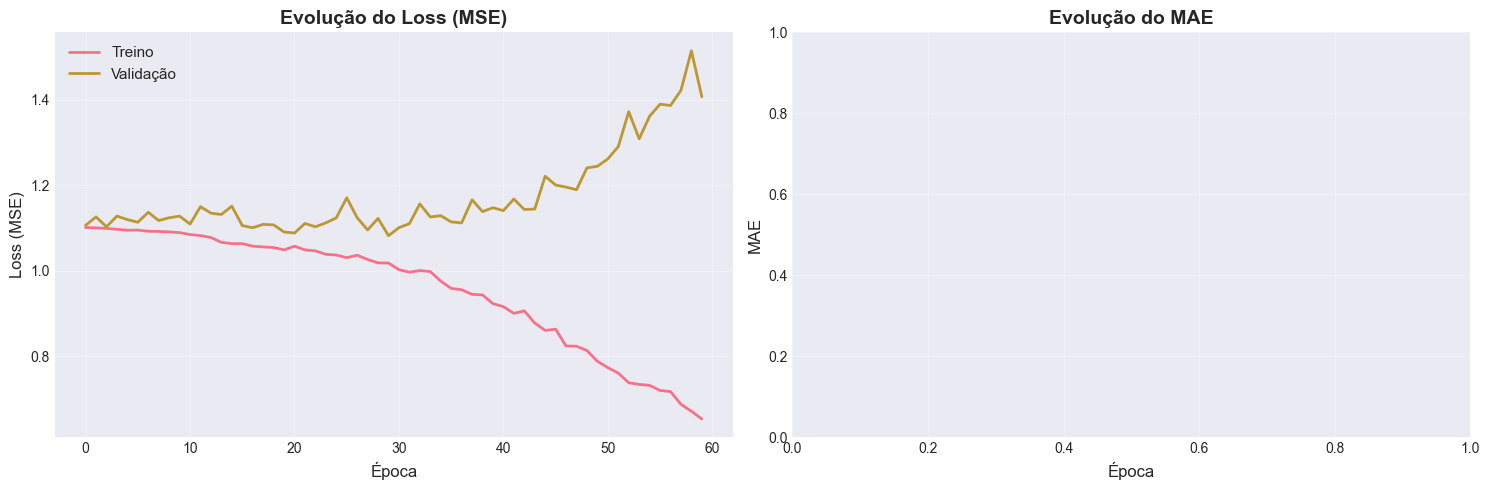


Treinamento parou na época: 60/100
Melhor val_loss (MSE): 1.082207


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss (MSE)
axes[0].plot(history.history['loss'], label='Treino', linewidth=2)
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Validação', linewidth=2)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Evolução do Loss (MSE)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE
if 'mae' in history.history:
    axes[1].plot(history.history['mae'], label='Treino', linewidth=2)
if 'val_mae' in history.history:
    axes[1].plot(history.history['val_mae'], label='Validação', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Evolução do MAE', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Informações sobre early stopping
stopped_epoch = len(history.history['loss'])
print(f"\nTreinamento parou na época: {stopped_epoch}/{EPOCHS}")
print(f"Melhor val_loss (MSE): {min(history.history.get('val_loss', [np.nan])):.6f}")
if 'val_mae' in history.history:
    print(f"Melhor val_mae: {min(history.history['val_mae']):.6f}")

## 10. Predições no Conjunto de Teste

In [13]:
print("Gerando predições (probabilidades multiclasse) no conjunto de teste...")

# --- CORREÇÃO: Removido o .flatten() ---
# Agora y_pred terá o shape (2899, 3)
y_pred = model.predict(X_test_seq)
# --- FIM DA CORREÇÃO ---

print(f"\n✓ Predições geradas")
print(f"  Shape y_test_seq (Gabarito): {y_test_seq.shape}")
print(f"  Shape y_pred (Probabilidades): {y_pred.shape}")

# Vamos analisar as probabilidades médias previstas para cada classe
print(f"\nProbabilidade média prevista (Classe 0, 1, 2):")
print(y_pred.mean(axis=0))

Gerando predições (probabilidades multiclasse) no conjunto de teste...
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

✓ Predições geradas
  Shape y_test_seq (Gabarito): (2899,)
  Shape y_pred (Probabilidades): (2899, 3)

Probabilidade média prevista (Classe 0, 1, 2):
[0.34936368 0.34371203 0.30692476]


## 11. Análise de Performance - Métricas de Classificação

Avaliação detalhada da performance do modelo em termos de erro acuracia

In [14]:
# CÉLULA 13 - AVALIAÇÃO DE PERFORMANCE (MÉTRICAS) - AGORA MULTICLASSE

print("="*60)
print(" " * 10 + "MÉTRICAS DE PERFORMANCE (CLASSIFICAÇÃO)")
print("="*60)

# --- MUDANÇA PRINCIPAL ---
# y_pred é um array de probabilidades (ex: [0.1, 0.6, 0.3])
# Usamos np.argmax para pegar o índice da maior probabilidade (ex: 1)
y_pred_class = np.argmax(y_pred, axis=1)
# --- FIM DA MUDANÇA ---

# 1. Acurácia (Nota Final)
accuracy = accuracy_score(y_test_seq, y_pred_class)
print(f"\n🎯 Acurácia (Taxa de Acerto): {accuracy * 100:.2f}%")
print("   (Esta é a porcentagem de vezes que o assistente acertou 'ALTA', 'NEUTRO' ou 'BAIXA' corretamente)")

# 2. Matriz de Confusão (Onde ele errou?)
print("\n📊 Matriz de Confusão:")
print("(Linhas=Real, Colunas=Previsto)")
cm = confusion_matrix(y_test_seq, y_pred_class)
print(cm)

# 3. Relatório Detalhado
print("\n📈 Relatório de Classificação Detalhado:")
print(classification_report(y_test_seq, y_pred_class, target_names=['Classe 0 (BAIXA)', 'Classe 1 (NEUTRO)', 'Classe 2 (ALTA)'], zero_division=0))

"""
# Converter as probabilidades (y_pred) em classes (0 ou 1)
# Se a probabilidade for > 0.5, o assistente acha que é 1 (ALTA)
y_pred_class = (y_pred > 0.5).astype(int)

print("="*60)
print(" " * 10 + "MÉTRICAS DE PERFORMANCE (CLASSIFICAÇÃO)")
print("="*60)

# 1. Acurácia (Nota Final)
accuracy = accuracy_score(y_test_seq, y_pred_class)
print(f"\n🎯 Acurácia (Taxa de Acerto): {accuracy * 100:.2f}%")
print("   (Esta é a porcentagem de vezes que o assistente acertou 'ALTA' ou 'BAIXA' corretamente)")

# 2. Matriz de Confusão (Onde ele errou?)
print("\n📊 Matriz de Confusão:")
print("(Linhas=Real, Colunas=Previsto)")
print(confusion_matrix(y_test_seq, y_pred_class))

# 3. Relatório Detalhado
print("\n📈 Relatório de Classificação Detalhado:")
print(classification_report(y_test_seq, y_pred_class, target_names=['Classe 0 (BAIXA)', 'Classe 1 (ALTA)'], zero_division=0))

"""

          MÉTRICAS DE PERFORMANCE (CLASSIFICAÇÃO)

🎯 Acurácia (Taxa de Acerto): 38.84%
   (Esta é a porcentagem de vezes que o assistente acertou 'ALTA', 'NEUTRO' ou 'BAIXA' corretamente)

📊 Matriz de Confusão:
(Linhas=Real, Colunas=Previsto)
[[280 164 196]
 [582 652 288]
 [376 167 194]]

📈 Relatório de Classificação Detalhado:
                   precision    recall  f1-score   support

 Classe 0 (BAIXA)       0.23      0.44      0.30       640
Classe 1 (NEUTRO)       0.66      0.43      0.52      1522
  Classe 2 (ALTA)       0.29      0.26      0.27       737

         accuracy                           0.39      2899
        macro avg       0.39      0.38      0.36      2899
     weighted avg       0.47      0.39      0.41      2899



'\n# Converter as probabilidades (y_pred) em classes (0 ou 1)\n# Se a probabilidade for > 0.5, o assistente acha que é 1 (ALTA)\ny_pred_class = (y_pred > 0.5).astype(int)\n\nprint("="*60)\nprint(" " * 10 + "MÉTRICAS DE PERFORMANCE (CLASSIFICAÇÃO)")\nprint("="*60)\n\n# 1. Acurácia (Nota Final)\naccuracy = accuracy_score(y_test_seq, y_pred_class)\nprint(f"\n🎯 Acurácia (Taxa de Acerto): {accuracy * 100:.2f}%")\nprint("   (Esta é a porcentagem de vezes que o assistente acertou \'ALTA\' ou \'BAIXA\' corretamente)")\n\n# 2. Matriz de Confusão (Onde ele errou?)\nprint("\n📊 Matriz de Confusão:")\nprint("(Linhas=Real, Colunas=Previsto)")\nprint(confusion_matrix(y_test_seq, y_pred_class))\n\n# 3. Relatório Detalhado\nprint("\n📈 Relatório de Classificação Detalhado:")\nprint(classification_report(y_test_seq, y_pred_class, target_names=[\'Classe 0 (BAIXA)\', \'Classe 1 (ALTA)\'], zero_division=0))\n\n'

## 12. Dispersão Predito vs Real


--- 9. Análise Visual das Previsões (Classificação) ---


C:\Users\User\AppData\Local\Temp\ipykernel_22012\2808004028.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test_seq, palette='viridis', stat='percent', order=[0, 1, 2])
C:\Users\User\AppData\Local\Temp\ipykernel_22012\2808004028.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred_class, palette='plasma', stat='percent', order=[0, 1, 2])


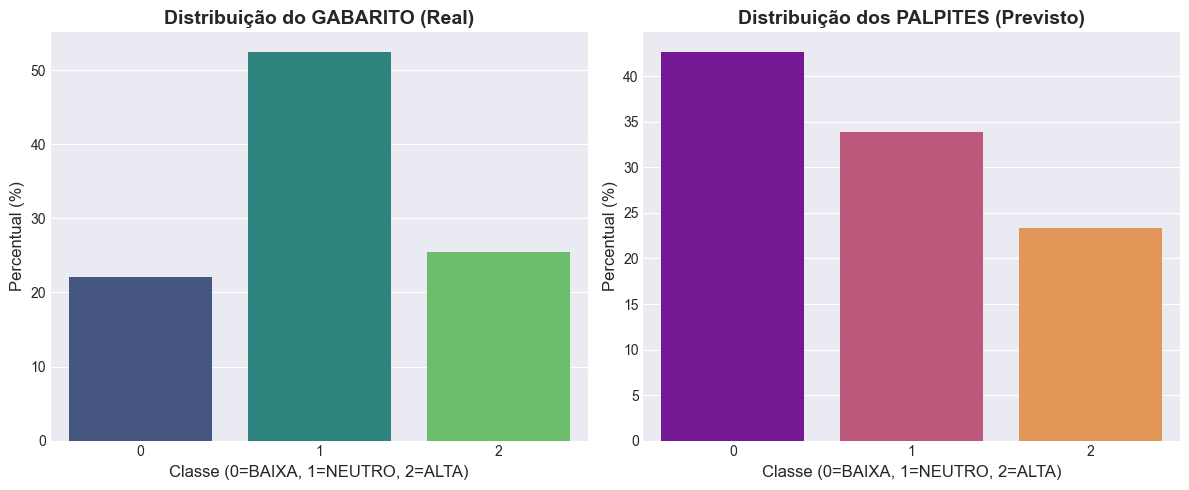


📊 ANÁLISE DO GRÁFICO:
   • Idealmente, o gráfico 'Previsto' deve ter uma distribuição parecida com o 'Real'.
   • Se o 'Previsto' mostrar 100% em uma única classe (ex: NEUTRO),
     significa que o assistente está 'trapaceando' e chutando a classe dominante.


In [15]:
# y_pred_class foi calculado na Célula 13. Se não, descomente a linha abaixo
# y_pred_class = np.argmax(y_pred, axis=1)

print("\n--- 9. Análise Visual das Previsões (Classificação) ---")

plt.figure(figsize=(12, 5))

# Gráfico 1: Distribuição do Gabarito Real (y_test_seq)
plt.subplot(1, 2, 1)
sns.countplot(x=y_test_seq, palette='viridis', stat='percent', order=[0, 1, 2])
plt.title('Distribuição do GABARITO (Real)', fontsize=14, fontweight='bold')
plt.xlabel('Classe (0=BAIXA, 1=NEUTRO, 2=ALTA)', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks([0, 1, 2])

# Gráfico 2: Distribuição dos Palpites (y_pred_class)
plt.subplot(1, 2, 2)
sns.countplot(x=y_pred_class, palette='plasma', stat='percent', order=[0, 1, 2])
plt.title('Distribuição dos PALPITES (Previsto)', fontsize=14, fontweight='bold')
plt.xlabel('Classe (0=BAIXA, 1=NEUTRO, 2=ALTA)', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks([0, 1, 2])

plt.tight_layout()
plt.show()

print("\n📊 ANÁLISE DO GRÁFICO:")
print("   • Idealmente, o gráfico 'Previsto' deve ter uma distribuição parecida com o 'Real'.")
print("   • Se o 'Previsto' mostrar 100% em uma única classe (ex: NEUTRO),")
print("     significa que o assistente está 'trapaceando' e chutando a classe dominante.")


--- 10. Análise de Confiança (Probabilidades) ---


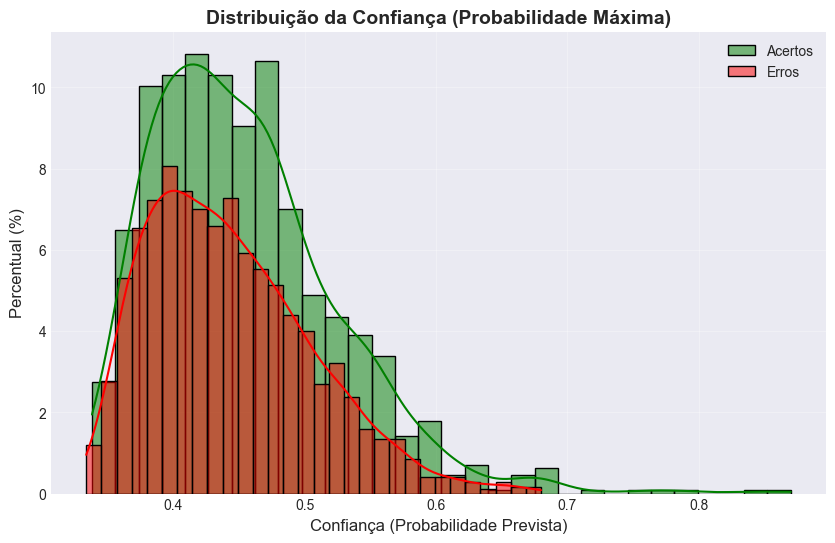


📊 ANÁLISE DO GRÁFICO:
   • Média de Confiança nos Acertos: 45.39%
   • Média de Confiança nos Erros:   44.28%

   • Idealmente, queremos ver o gráfico 'Acertos' (verde) concentrado à direita (alta confiança),
     e o gráfico 'Erros' (vermelho) concentrado à esquerda (baixa confiança).
   • Se os dois gráficos estiverem muito sobrepostos, o modelo não sabe quando está errando.


In [16]:
# ANÁLISE DE CONFIANÇA DO MODELO

print("\n--- 10. Análise de Confiança (Probabilidades) ---")

# Pega a maior probabilidade (confiança) de cada previsão
prob_confidence = np.max(y_pred, axis=1)

# Separa a confiança dos acertos e dos erros
correct_predictions_mask = (y_pred_class == y_test_seq)
confidence_acertos = prob_confidence[correct_predictions_mask]
confidence_erros = prob_confidence[~correct_predictions_mask]

plt.figure(figsize=(10, 6))
sns.histplot(confidence_acertos, bins=30, kde=True, color='green', label='Acertos', stat='percent')
sns.histplot(confidence_erros, bins=30, kde=True, color='red', label='Erros', stat='percent')
plt.title('Distribuição da Confiança (Probabilidade Máxima)', fontsize=14, fontweight='bold')
plt.xlabel('Confiança (Probabilidade Prevista)', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n📊 ANÁLISE DO GRÁFICO:")
print(f"   • Média de Confiança nos Acertos: {np.mean(confidence_acertos)*100:.2f}%")
print(f"   • Média de Confiança nos Erros:   {np.mean(confidence_erros)*100:.2f}%")
print("\n   • Idealmente, queremos ver o gráfico 'Acertos' (verde) concentrado à direita (alta confiança),")
print("     e o gráfico 'Erros' (vermelho) concentrado à esquerda (baixa confiança).")
print("   • Se os dois gráficos estiverem muito sobrepostos, o modelo não sabe quando está errando.")

## 15. Análise de Confiança


--- 10. Análise de Confiança (Probabilidades) ---


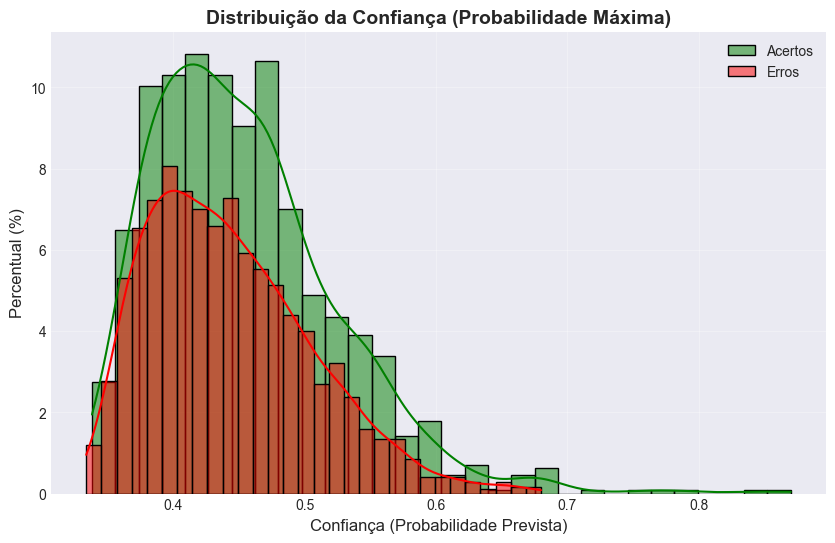


📊 ANÁLISE DO GRÁFICO:
   • Média de Confiança nos Acertos: 45.39%
   • Média de Confiança nos Erros:   44.28%

   • Idealmente, queremos ver o gráfico 'Acertos' (verde) concentrado à direita (alta confiança),
     e o gráfico 'Erros' (vermelho) concentrado à esquerda (baixa confiança).
   • Se os dois gráficos estiverem muito sobrepostos, o modelo não sabe quando está errando.


In [18]:
print("\n--- 10. Análise de Confiança (Probabilidades) ---")

# Pega a maior probabilidade (confiança) de cada previsão
prob_confidence = np.max(y_pred, axis=1)

# Separa a confiança dos acertos e dos erros
correct_predictions_mask = (y_pred_class == y_test_seq)
confidence_acertos = prob_confidence[correct_predictions_mask]
confidence_erros = prob_confidence[~correct_predictions_mask]

plt.figure(figsize=(10, 6))
sns.histplot(confidence_acertos, bins=30, kde=True, color='green', label='Acertos', stat='percent')
sns.histplot(confidence_erros, bins=30, kde=True, color='red', label='Erros', stat='percent')
plt.title('Distribuição da Confiança (Probabilidade Máxima)', fontsize=14, fontweight='bold')
plt.xlabel('Confiança (Probabilidade Prevista)', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n📊 ANÁLISE DO GRÁFICO:")
print(f"   • Média de Confiança nos Acertos: {np.mean(confidence_acertos)*100:.2f}%")
print(f"   • Média de Confiança nos Erros:   {np.mean(confidence_erros)*100:.2f}%")
print("\n   • Idealmente, queremos ver o gráfico 'Acertos' (verde) concentrado à direita (alta confiança),")
print("     e o gráfico 'Erros' (vermelho) concentrado à esquerda (baixa confiança).")
print("   • Se os dois gráficos estiverem muito sobrepostos, o modelo não sabe quando está errando.")

## 16. Resumo Final e Conclusões

In [22]:
# --- CÉLULA 16 (Substitua o código por este) ---

print("\n" + "="*70)
print(" "*20 + "RESUMO FINAL DA ANÁLISE")
print("="*70)

print(f"\n📋 CONFIGURAÇÃO DO MODELO:")
print(f"  • Ticker: {TICKER}")
print(f"  • Timeframe: {timeframe_str}")
print(f"  • Período: {START_DATE.date()} a {END_DATE.date()}")
print(f"  • Total de candles: {len(df_raw)}")
print(f"  • Lookback: {LOOKBACK}")
print(f"  • LSTM Units: {LSTM_UNITS}")
print(f"  • Features utilizadas: {len(FEATURE_NAMES)}")
print(f"  • Épocas treinadas: {stopped_epoch}/{EPOCHS}")

# --- SEÇÃO DE RESULTADOS ATUALIZADA ---
print(f"\n📊 RESULTADOS DE PERFORMANCE (CLASSIFICAÇÃO):")
# Garante que a variável 'accuracy' foi calculada na Célula 11
if 'accuracy' in locals():
    print(f"  • 🎯 Acurácia (Nota Final): {accuracy * 100:.2f}%")
else:
    print("  • 🎯 Acurácia (Nota Final): (Variável 'accuracy' não encontrada)")

print(f"\n  • 📈 Relatório Detalhado: (Ver Célula 11)")
print(f"  • 📊 Matriz de Confusão:  (Ver Célula 11)")
# --- FIM DA SEÇÃO ATUALIZADA ---


print(f"\n✅ ANÁLISE QUALITATIVA:")
print("  • Acurácia: Mostra a 'nota final' geral do assistente.")
print("  • Relatório Detalhado: É a parte mais importante. Mostra a capacidade")
print("    do assistente em acertar 'ALTA' (Classe 1), que é o evento raro.")
print("  • Foco no 'recall' e 'precision' da Classe 1.")


print(f"\n⚠️  CONSIDERAÇÕES:")
print(f"  • O 'gabarito' é altamente desbalanceado ({df_clean['target'].mean()*100:.2f}% de 'ALTAS').")
print(f"  • O modelo pode 'viciar' em prever apenas 'BAIXA' (Classe 0).")
print(f"  • É essencial usar 'class_weight' (como na Proposta 2) para forçar")
print(f"    o modelo a aprender os padrões da Classe 1.")

print("\n" + "="*70 + "\n")


                    RESUMO FINAL DA ANÁLISE

📋 CONFIGURAÇÃO DO MODELO:
  • Ticker: WDO$
  • Timeframe: H1
  • Período: 2020-01-01 a 2024-12-31
  • Total de candles: 9766
  • Lookback: 30
  • LSTM Units: 100
  • Features utilizadas: 9
  • Épocas treinadas: 60/100

📊 RESULTADOS DE PERFORMANCE (CLASSIFICAÇÃO):
  • 🎯 Acurácia (Nota Final): 38.84%

  • 📈 Relatório Detalhado: (Ver Célula 11)
  • 📊 Matriz de Confusão:  (Ver Célula 11)

✅ ANÁLISE QUALITATIVA:
  • Acurácia: Mostra a 'nota final' geral do assistente.
  • Relatório Detalhado: É a parte mais importante. Mostra a capacidade
    do assistente em acertar 'ALTA' (Classe 1), que é o evento raro.
  • Foco no 'recall' e 'precision' da Classe 1.

⚠️  CONSIDERAÇÕES:
  • O 'gabarito' é altamente desbalanceado (99.17% de 'ALTAS').
  • O modelo pode 'viciar' em prever apenas 'BAIXA' (Classe 0).
  • É essencial usar 'class_weight' (como na Proposta 2) para forçar
    o modelo a aprender os padrões da Classe 1.




## 🎯 Conclusão

Este notebook implementou e analisou uma LSTM para predição de movimentos de mercado, seguindo fielmente a arquitetura do projeto WTNPS Trade.

**Próximos passos sugeridos:**
1. Experimentar com diferentes lookbacks (30, 90, 120)
2. Testar diferentes conjuntos de features
3. Ajustar hiperparâmetros (LSTM units, dropout, learning rate)
4. Implementar validação temporal (walk-forward)
5. Integrar com análise de setup (filtros de entrada)
6. Realizar backtest completo com gestão de risco